# How ToMATo Works

### Introduction

ToMATo was originally introduced by [Chazal, Guibas, Oudot, and Skraba](https://geometry.stanford.edu/paper/cgos-pbcrm-11/cgos-pbcrm-11.pdf). At its core, ToMATo combines **mode-seeking** and **topological persistence** to find stable clusters in data. It is an early example of a hierarachical, density-based clustering algorithm that runs in near-linear time. For more information on topological persistence for graphs, see Chapter 3.5 of [*Computational Topology for Data Analysis* by Wang and Dey (2021)](https://yusu.belkin-wang.org/CTDAbook-DeyWang.pdf).

### Motivation

This implementation of ToMATo was developed to provide a fast and "feature-complete" clustering algorithm, supporting:
- Hierarchical, density-based clustering
- *Optional* noise-awareness
- *Optional* number of clusters specification
- Assignment probabilities
- Soft clustering
- Out-of-sample prediction
- Spatially constrained regionalization

The development package was motivated by the author's admiration for [HDBSCAN](https://github.com/scikit-learn-contrib/hdbscan). HDBSCAN is a fast, hierarchical density-based clustering algorithm with an incredibly rich feature set. It does not, however, provide the ability to make noise-awareness optional, to easily control noise, or to specify a specific number of clusters to return. HDBSCAN's performance can also break down for very large datasets. Hopefully this package demonstrates how these needs might be addressed in clustering tools.

Given that ToMATo is so similar to HDBSCAN in its philosophy and aims, this notebook will seek to compare ToMATo to HDBSCAN. This will help to highlight exactly where the algorithms differ, as well as the upshots of approaching things the way that ToMATo does.

## I. Getting Some Data

To demonstrate how ToMATo works, we'll of course need some data to start with. We'll use the same test data that HDBSCAN uses for demonstration in their notebook, [How HDBSCAN Works](https://github.com/scikit-learn-contrib/hdbscan/blob/master/notebooks/How%20HDBSCAN%20Works.ipynb).

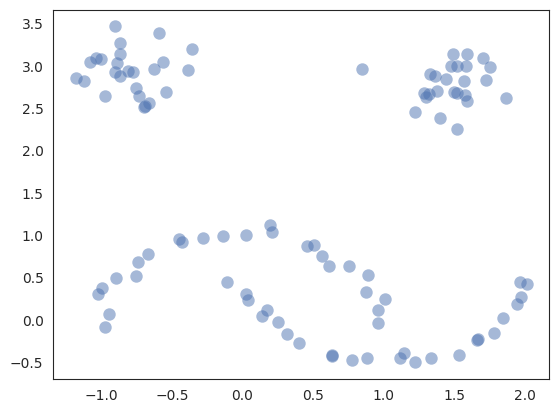

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets as data

%matplotlib inline

sns.set_style('white')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.5, 's' : 80, 'linewidths':0}


moons, _ = data.make_moons(n_samples=50, noise=0.05, random_state=42)
blobs, _ = data.make_blobs(n_samples=50, centers=[(-0.75, 3.0), (1.5, 2.75)], cluster_std=0.25, random_state=42)
test_data = np.vstack([moons, blobs])
plt.scatter(test_data.T[0], test_data.T[1], color='b', **plot_kwds)

## II. Clustering the Data

The next thing we'll need to do is import our clustering tool and fit it to our test data. While we're at it, we'll import a tool for visualizing the results and inner workings of ToMATo clustering that we'll use throughout this notebook.

In [2]:
from tomato import ToMATo
from tomato.visualization import ToMAToVisualization

In [3]:
clf = ToMATo(n_neighbors=4, random_state=42, enforce_connected=True)
clf.fit(test_data)

Let's take a look at the clustering that ToMATo produced.

In [4]:
viz = ToMAToVisualization(clf)

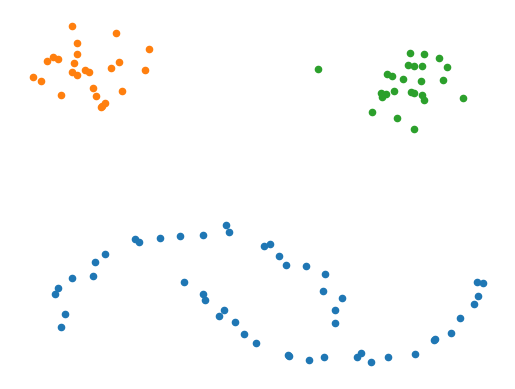

In [5]:
fig = viz.plot_labels()

This looks good! But...

### What did ToMATo just do?

Giving this question a good answer is what we'll try to do by the end of this notebook. ToMATo, while rooted in some advanced mathematics, is actually a relatively simple algorithm at its core. Its operation can be outlined in just a handful of steps:
1. Construct a neighborhood graph equipped with a density function.
2. Use gradient ascent/descent to find modes (critical points) of this density function.
3. Merge modes using a minimum spanning tree.
4. Pick the most persistent modes from the MST as clusters.

Below, we'll walk through each of these steps individually, using visualizations to get a feel for how ToMATo works.

## III. ToMATo Step By Step


### 1. Building the Graph and Calculating Density

ToMATo kicks things off by constructing a k-nearest neighbors graph, with edges weighted by distance. The edge weights are then used to calculate **distance-to-measure** values at each vertex, which serve as an inverted proxy for density in the data. Distance-to-measure is defined by the authors of the ToMATo paper, and in this implementation, we will use an approximation given by RMS:

$\text{DTM}(x) = \sqrt{\mu(d(x, x_i)^2)}, \quad x_i \text{ is a neighbor of } x$

This implementation of ToMATo can optionally merge disconnected components of the KNN graph to ensure that later cluster merging operations are well-behaved. In most datasets, we will only need a few edges to ensure the KNN graph is connected, making the search for minimal spanning edges quite cheap. In the graph for our example dataset, visualized in the plot below, these long-distance minimum spanning edges will appear in red:

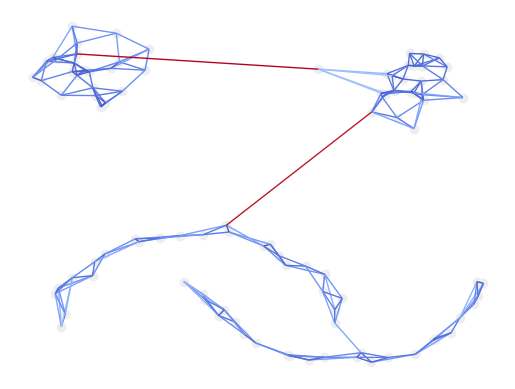

In [6]:
fig = viz.plot_graph(cmap="coolwarm")

### 2. Finding Gradients & Local Minima

After the graph has been built and equipped with a density function, ToMATo searches the graph for descending gradients. At each vertex in the graph, ToMATo looks for the outoging edge with the lowest weight, and takes this (directed) edge to be the gradient at that vertex *if the neighboring vertex at that edge has a lower function value*. Each such edge points in the direction of steepest descent.

With descending gradients in hand, we can now look for vertices with zero outgoing edges. These are vertices that don't have any neighbors which decrease the function value, so they are local minima of the vertex function.

Below, we'll plot the local gradient edges, and show which points are identified as local minima:

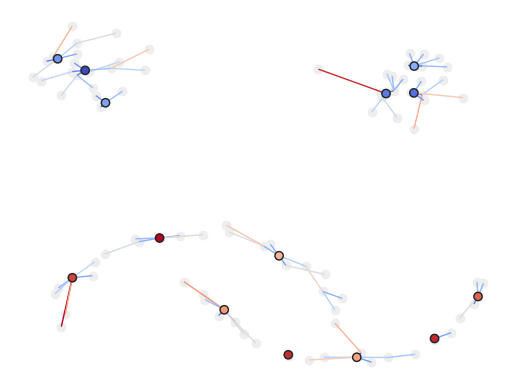

In [7]:
fig = viz.plot_gradient(cmap="coolwarm")

### 3. Merging Components

The local minima we just found tell us where our data is the most dense. This is what we want out of clustering: to find contiguous, dense regions in our data. However, there are many critical points in the data, due to how noisy our estimate of density is. We need some way to simplify the density structure and determine which regions are the "most stable" dense regions in the data.

To do this, we can merge critical points into progressively larger clusters using a simplified minimum spanning tree (MST) computed only on the critical points. Near the leaves of the tree, the MST will merge locally dense critical points into other, locally dense critical points. Near the root of the tree, the MST will merge distant, sparse regions in the data. In this sense, the MST orders the critical points by their persistence with respect to the density function.

Because the MST is computed only on the critical points, and not our entire dataset, this ends up being very fast to compute regardless of which specific algorithm we use to calculate the MST.

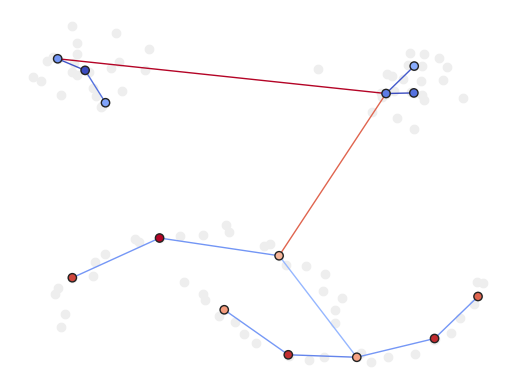

In [8]:
fig = viz.plot_mst(cmap="coolwarm")

### 4. Extracting Clusters

To choose a final clustering of our data, we simply need to prune the MST along its longest edges.

To do this, it would be helpful to have an intuitive notion of when an edge is "long enough" to prune. How do we determine a threshold for this? Luckily, the MST can be visualized in terms of the "persistence" of its vertices. The persistence of a vertex is simply the difference between the scale at which a vertex was determined to be a critical point (its function value), and the scale at which it was merged in the MST (the function value of its parent vertex).

When we plot these, we often see a natural and sudden "jump" in the persistence scores, corresponding to the most natural clustering in the data. We can calculate the scale at which the largest jump occurs and use it as a default threshold for pruning the MST.

There are many ways to choose a threshold, though. One can specify a threshold that produces a specific number of clusters, choose based on statistical significance, or just specify a custom value altogether if there's one that seems reasonable a priori. The implementation of ToMATo in this package supports all of these approaches. For this example, we'll stick with the default "largest jump" threshold.

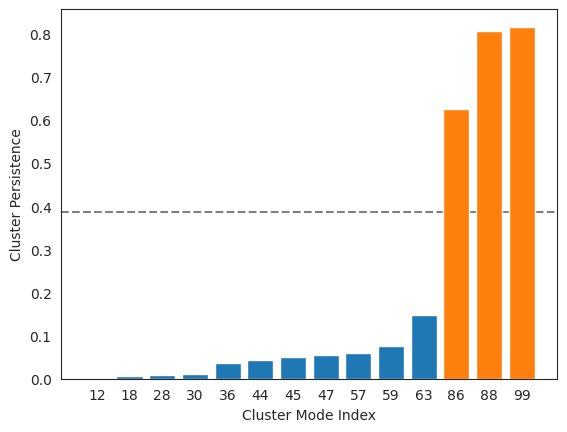

In [9]:
fig = viz.plot_cluster_persistences()

Now we just prune the MST at this threshold and pull back our clusters.

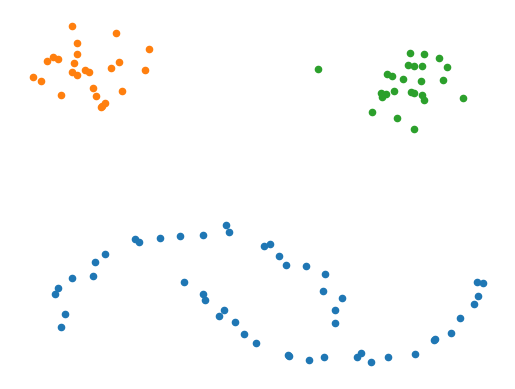

In [10]:
fig = viz.plot_labels()

And that's ToMATo! Hopefully this exposition did some justice to the elegance of the algorithm. The ToMATo algorithm is incredibly flexible, and will work with any graph and any function, really. Perhaps there are celverer ways to build the neighborhood graph or estimate density for datasets; experimentation along these line is strongly encouraged!